SMR: Structure · Metrics · Reasoning

Purpose
Explain why customers are satisfied or dissatisfied, using delivery performance as the primary driver and identifying category-level business risk.

Analytical flow

Overall review landscape

Delivery delay → review score relationship

Delay severity buckets

Category-level satisfaction

Composite return-risk modeling

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Paths
order_path = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv")
item_path  = Path(r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_item_level.csv")

# Load datasets
orders = pd.read_csv(
    order_path,
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

items = pd.read_csv(item_path)


Overall Review Landscape (Context)

Core review metrics

In [2]:
avg_review_score = orders["review_score"].mean()
median_review_score = orders["review_score"].median()
review_count = orders["review_score"].count()

print(f"Average review score: {avg_review_score:.2f}")
print(f"Median review score: {median_review_score}")
print(f"Total reviews: {review_count}")


Average review score: 4.09
Median review score: 5.0
Total reviews: 98167


#### Review distribution

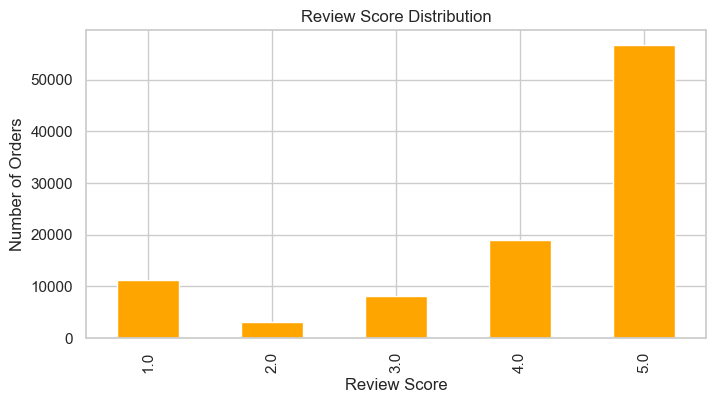

In [3]:
orders["review_score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,4),
    color="orange"
)
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.show()


### Q4 Review Scores vs Delivery Delay

#### Late vs On-time flag

In [4]:
orders["is_late"] = orders["delivery_delay_days"] > 0


#### Delay severity buckets

In [5]:
orders["delay_bucket"] = pd.cut(
    orders["delivery_delay_days"],
    bins=[-100, -0.01, 0, 3, 100],
    labels=["Early", "On-time", "Late (1–3 days)", "Very late (>3 days)"]
)


#### Average review score by delay bucket

In [6]:
delay_review_summary = orders.groupby("delay_bucket").agg(
    avg_review_score=("review_score", "mean"),
    review_volume=("review_score", "count")
)

delay_review_summary


C:\Users\Admin\AppData\Local\Temp\ipykernel_56220\93462008.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_review_summary = orders.groupby("delay_bucket").agg(


,avg_review_score,review_volume
delay_bucket,,
Early,4.297089,86900
On-time,4.129032,1364
Late (1–3 days),3.617418,2308
Very late (>3 days),1.893608,4756


#### Bar chart — Avg review score by delay bucket

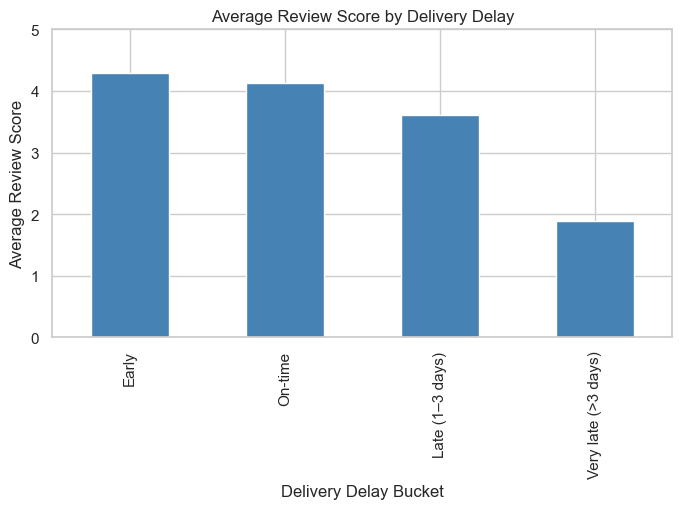

In [7]:
delay_review_summary["avg_review_score"].plot(
    kind="bar",
    figsize=(8,4),
    color="steelblue"
)
plt.title("Average Review Score by Delivery Delay")
plt.ylabel("Average Review Score")
plt.xlabel("Delivery Delay Bucket")
plt.ylim(0,5)
plt.show()


#### Box plot — Review distribution by delay bucket

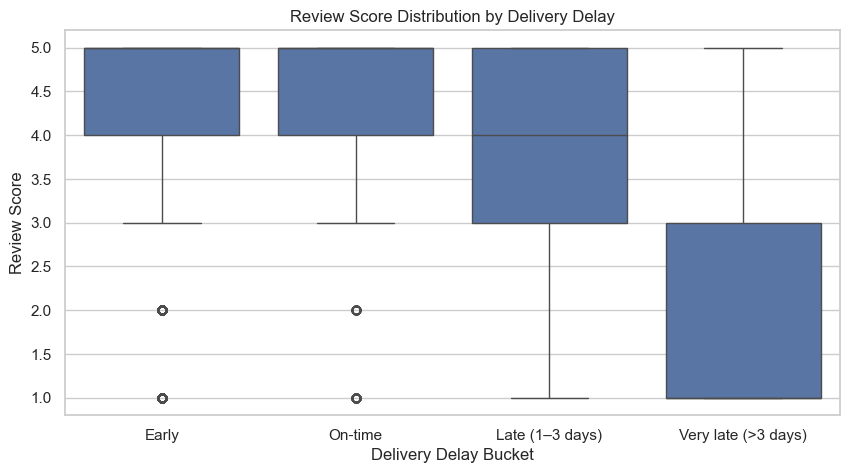

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="delay_bucket",
    y="review_score",
    data=orders
)
plt.title("Review Score Distribution by Delivery Delay")
plt.xlabel("Delivery Delay Bucket")
plt.ylabel("Review Score")
plt.show()


### Q5 Lowest-Rated Categories & Return-Risk Signals

#### Attach category to order-level reviews

In [9]:
order_category = (
    items[["order_id", "product_category_name"]]
    .drop_duplicates()
)

orders_cat = orders.merge(
    order_category,
    on="order_id",
    how="left"
)


#### Category-level aggregation

In [10]:
category_metrics = orders_cat.groupby("product_category_name").agg(
    avg_review_score=("review_score", "mean"),
    avg_delivery_time=("delivery_time_days", "mean"),
    delay_rate=("is_late", "mean"),
    order_volume=("order_id", "count")
).dropna()

category_metrics.head()


,avg_review_score,avg_delivery_time,delay_rate,order_volume
product_category_name,,,,
agro_industria_e_comercio,4.021978,11.000000,0.043956,182
alimentos,4.287982,9.335601,0.084444,450
alimentos_bebidas,4.381166,10.398190,0.048458,227
artes,4.040201,10.774359,0.069307,202
artes_e_artesanato,4.173913,5.391304,0.043478,23


#### Composite Return-Risk Index

In [11]:
category_metrics["return_risk_index"] = (
    (1 / category_metrics["avg_review_score"]) *
    category_metrics["avg_delivery_time"]
)


#### Top 10 highest-risk categories

In [12]:
top_risk_categories = category_metrics.sort_values(
    "return_risk_index",
    ascending=False
).head(10)

top_risk_categories


,avg_review_score,avg_delivery_time,delay_rate,order_volume,return_risk_index
product_category_name,,,,,
seguros_e_servicos,2.500000,15.000000,0.000000,2,6.000000
moveis_escritorio,3.617834,20.173046,0.085625,1273,5.576000
artigos_de_natal,4.055556,14.936000,0.093750,128,3.682849
casa_conforto_2,3.826087,14.000000,0.166667,24,3.659091
moveis_colchao_e_estofado,3.828571,13.891892,0.131579,38,3.628479
fashion_calcados,4.235043,15.242553,0.054167,240,3.599150
fashion_underwear_e_moda_praia,3.940171,13.564103,0.115702,121,3.442516
casa_conforto,3.878173,13.232143,0.100756,397,3.411953
audio,3.835735,13.028736,0.122857,350,3.396673


### Bar chart — Top 10 return-risk categories

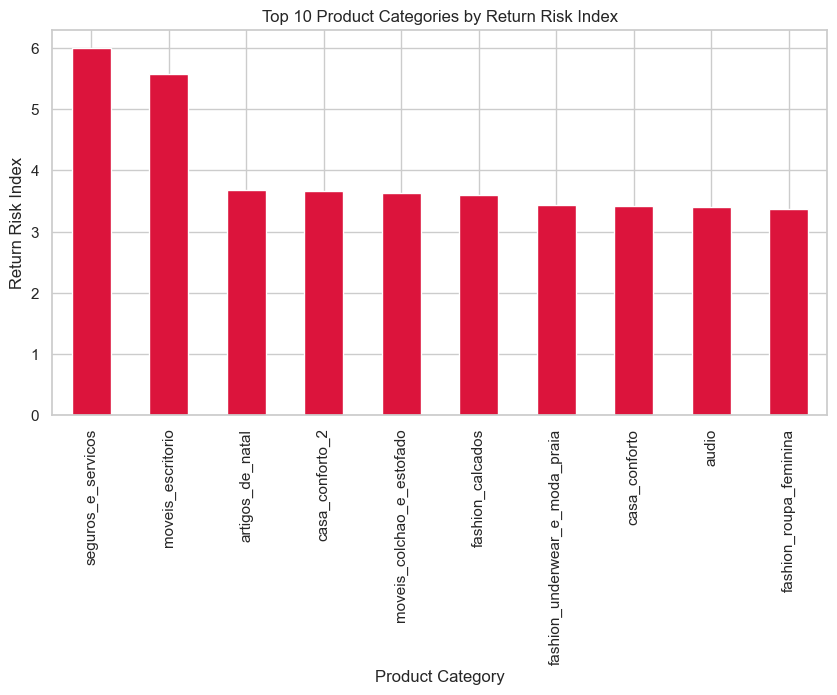

In [13]:
top_risk_categories["return_risk_index"].plot(
    kind="bar",
    figsize=(10,5),
    color="crimson"
)
plt.title("Top 10 Product Categories by Return Risk Index")
plt.ylabel("Return Risk Index")
plt.xlabel("Product Category")
plt.show()


#### Scatter plot — Satisfaction vs Delivery Time (Risk Map)

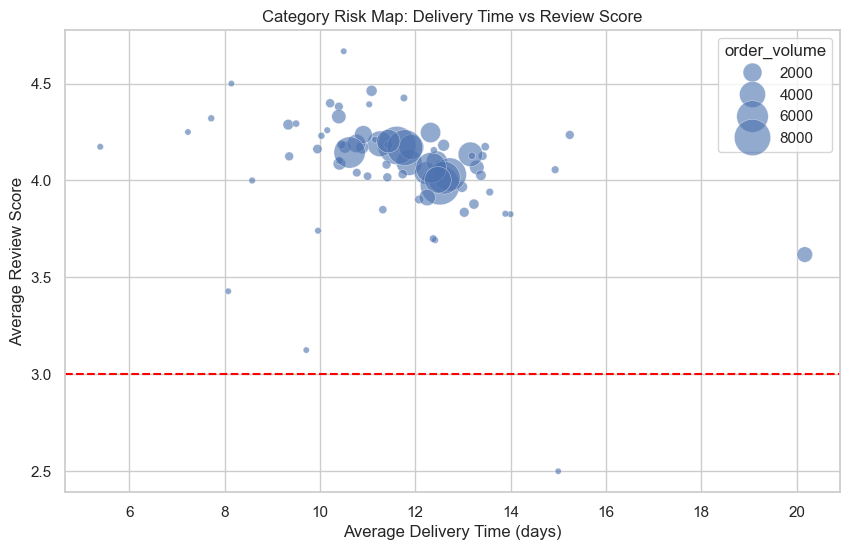

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=category_metrics,
    x="avg_delivery_time",
    y="avg_review_score",
    size="order_volume",
    sizes=(20, 800),
    alpha=0.6
)

plt.title("Category Risk Map: Delivery Time vs Review Score")
plt.xlabel("Average Delivery Time (days)")
plt.ylabel("Average Review Score")
plt.axhline(3, linestyle="--", color="red")
plt.show()


### Key Analytical Outputs

##### Categories with BOTH low reviews & high volume

In [15]:
high_impact_low_satisfaction = category_metrics[
    (category_metrics["avg_review_score"] < 3) &
    (category_metrics["order_volume"] > category_metrics["order_volume"].median())
]

high_impact_low_satisfaction.sort_values("avg_review_score").head()


,avg_review_score,avg_delivery_time,delay_rate,order_volume,return_risk_index
product_category_name,,,,,


Findings


Delivery delay has a strong, non-linear negative effect on review scores

Severe delays cause disproportionate dissatisfaction

Some categories combine poor reviews, slow delivery, and high volume

These categories represent elevated return and churn risk

Business Implication

Operational improvements should prioritize high-risk categories rather than high-revenue categories alone.


Transition 

Having established the operational drivers of customer dissatisfaction, the next analysis focuses on seller-level accountability, identifying which sellers contribute most to delivery failures and poor customer experiences.